# COMP 4980 – Machine Learning Final Project
## Video Game Sales Prediction (vgsales.csv)
### Experiment Notebook

Rafid Hasan – T00695541

 This notebook contains all experiments, analysis steps, and model evaluations for my final project. The goal is to perform a full machine-learning workflow—data cleaning, exploratory analysis, PCA, decision-tree exploration, feature engineering, and testing multiple classification models—to determine whether a video game becomes a high-selling title.

Imports and Config:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


Load the Dataset:

In [ ]:
df = pd.read_csv("vgsales.csv")

df.head()


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Quick Overview:

In [ ]:
df.info()
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rank,16598.0,NaN,NaN,NaN,8300.605254,4791.853933,1.0,4151.25,8300.5,12449.75,16600.0
Name,16598,11493,Need for Speed: Most Wanted,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,16598,31,DS,2163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,16327.0,NaN,NaN,NaN,2006.406443,5.828981,1980.0,2003.0,2007.0,2010.0,2020.0
Genre,16598,12,Action,3316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publisher,16540,578,Electronic Arts,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA_Sales,16598.0,NaN,NaN,NaN,0.264667,0.816683,0.0,0.0,0.08,0.24,41.49
EU_Sales,16598.0,NaN,NaN,NaN,0.146652,0.505351,0.0,0.0,0.02,0.11,29.02
JP_Sales,16598.0,NaN,NaN,NaN,0.077782,0.309291,0.0,0.0,0.0,0.04,10.22
Other_Sales,16598.0,NaN,NaN,NaN,0.048063,0.188588,0.0,0.0,0.01,0.04,10.57


In [ ]:
# Dropping rows with missing year or sales
df = df.dropna(subset=['Year', 'Global_Sales'])

# Making Year integer and restricting range
df['Year'] = df['Year'].astype(int)
df = df[(df['Year'] >= 1980) & (df['Year'] <= 2016)]

# Binary target: high-selling if Global_Sales >= 1 million units
df['High_Sales'] = (df['Global_Sales'] >= 1.0).astype(int)

# Checking the distribution of the target
print(df['High_Sales'].value_counts())
print(df['High_Sales'].value_counts(normalize=True))

df.head()


High_Sales
0    14264
1     2059
Name: count, dtype: int64
High_Sales
0    0.873859
1    0.126141
Name: proportion, dtype: float64


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,High_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,1
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,1
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,1
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,1
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1


*   I removed entries with missing Year and Global_Sales.
*   I limited the data to games released between 1980 and 2016.
*   I defined a high-selling game as one with Global_Sales ≥ 1 million units, stored as High_Sales (0/1).


Global Sales Distribution:

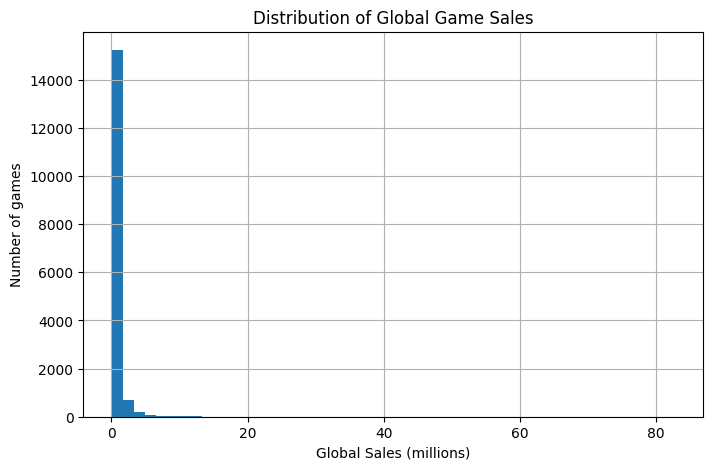

In [ ]:
plt.hist(df['Global_Sales'], bins=50)
plt.xlabel("Global Sales (millions)")
plt.ylabel("Number of games")
plt.title("Distribution of Global Game Sales")
plt.show()


The distribution of global sales is extremely skewed, with most games selling under one million units and only a very small number achieving very high sales. Because of this long-tail distribution, predicting the exact number of sales using regression would be unstable and inaccurate. Instead, converting the target variable into a binary label (high-selling vs low-selling) creates a more balanced and meaningful prediction problem. This allows the models to focus on distinguishing successful games from typical low-selling titles, which is more realistic and easier to interpret.


Average sales by genre:

Genre
Platform        0.946518
Shooter         0.800468
Role-Playing    0.628863
Racing          0.592798
Sports          0.568247
Fighting        0.531160
Action          0.529788
Misc            0.466444
Simulation      0.458671
Puzzle          0.424203
Strategy        0.258465
Adventure       0.184013
Name: Global_Sales, dtype: float64


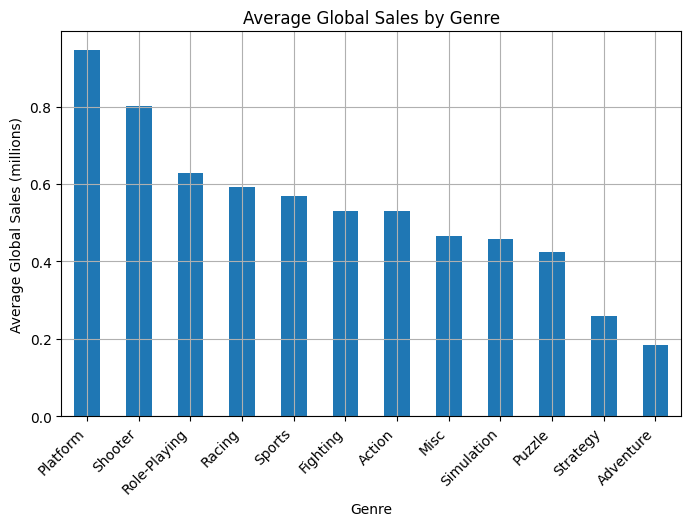

In [ ]:
genre_sales = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
print(genre_sales)

genre_sales.plot(kind='bar')
plt.ylabel("Average Global Sales (millions)")
plt.title("Average Global Sales by Genre")
plt.xticks(rotation=45, ha='right')
plt.show()


Different genres show clear differences in average global sales. Platform, Shooter, and Role-Playing games have the highest average sales, likely due to the popularity of major franchises within these genres. On the other hand, Puzzle, Strategy, and Adventure games show much lower average sales, which indicates that these genres tend to target smaller or more niche audiences. This suggests that genre may be an important predictor in determining whether a game becomes high-selling.

Number of gamers per platform:

Platform
DS      2132
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
GC       542
3DS      500
PSV      410
PS4      335
N64      316
Name: count, dtype: int64


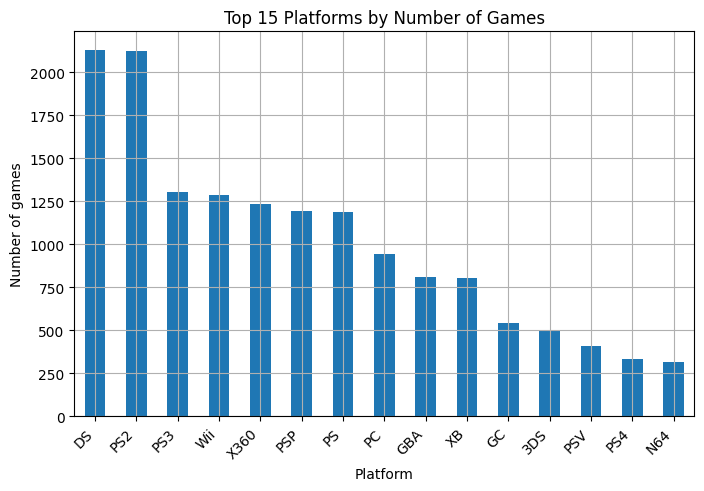

In [ ]:
platform_counts = df['Platform'].value_counts().head(15)
print(platform_counts)

platform_counts.plot(kind='bar')
plt.ylabel("Number of games")
plt.title("Top 15 Platforms by Number of Games")
plt.xticks(rotation=45, ha='right')
plt.show()


The platform frequency chart shows that consoles like the Nintendo DS, PlayStation 2, PlayStation 3, and Wii have the highest number of game releases. This aligns with the years where these consoles dominated the market. The large number of titles also suggests that some platforms have more diverse game libraries. However, a high number of releases does not necessarily mean higher sales per game, meaning platform alone might not fully explain whether a game becomes high-selling.
Newer consoles like PS4 have fewer titles because the dataset ends around 2016.


The High_Sales label is imbalanced: only around 13% of games sell over one million units. Because of this imbalance, accuracy alone may not be a perfect evaluation metric, and precision/recall will be important in the analysis of model performance.

Total global sales per year:

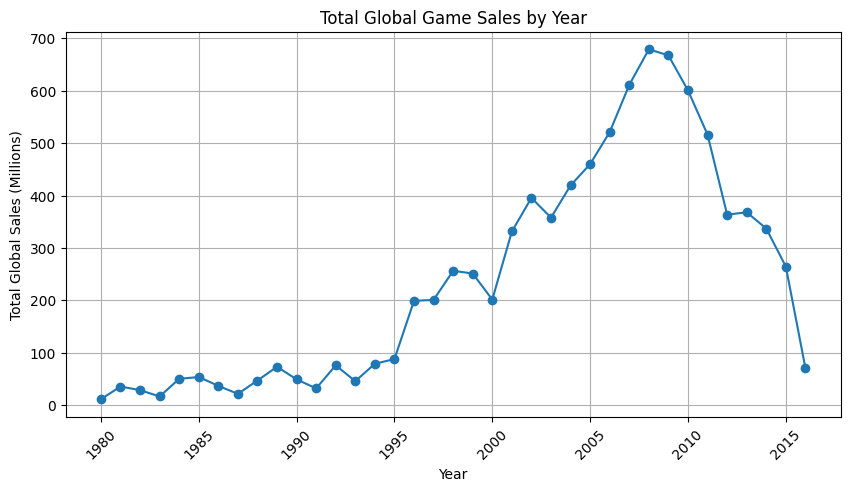

In [ ]:
sales_by_year = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o')
plt.title("Total Global Game Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Global Sales (Millions)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


The total global sales by year show a clear upward trend from the early 1980s until around 2008–2010, which appears to be the peak of the dataset. This period corresponds with the dominance of consoles like the Nintendo Wii, Xbox 360, and PlayStation 3, which were part of a major growth phase in the gaming industry. After 2010, the total sales begin to decline, likely because the dataset ends around 2016, and also due to the rise of mobile and digital distribution platforms which are not fully captured in this dataset.


Number of games released per year:

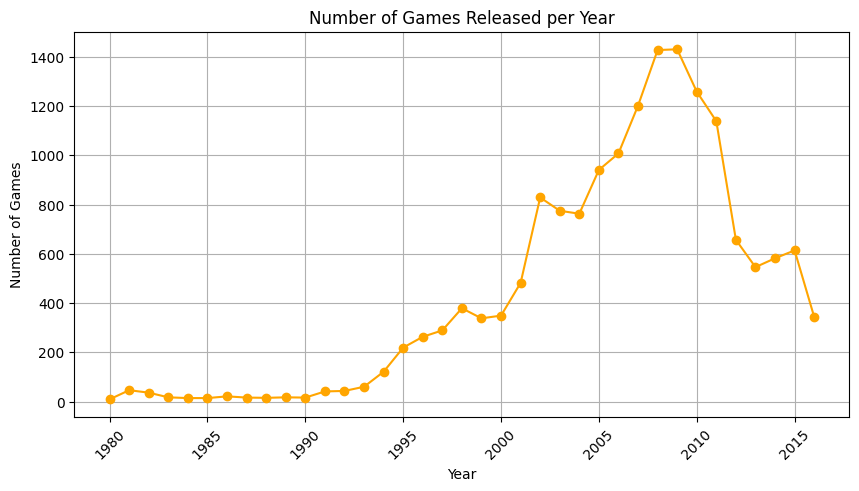

In [ ]:
count_by_year = df.groupby('Year')['Name'].count()

plt.figure(figsize=(10,5))
plt.plot(count_by_year.index, count_by_year.values, marker='o', color='orange')
plt.title("Number of Games Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


The number of games released per year increases steadily from the 1980s to the mid-2000s. The peak release period is between 2007 and 2012, where the Nintendo DS, Wii, PlayStation 2/3, and Xbox 360 all had large active libraries. After 2012, the number of releases decreases, which is consistent with the dataset's coverage ending in 2016 and the transition toward digital-only releases that may not be fully represented in this dataset.


Grouping:

In [ ]:
# Make a working copy
data = df.copy()

# --- Era Feature ---
def year_to_era(year):
    if year < 1990:
        return "1980s"
    elif year < 2000:
        return "1990s"
    elif year < 2010:
        return "2000s"
    else:
        return "2010s"

data['Era'] = data['Year'].apply(year_to_era)

# --- Publisher_Group Feature ---
publisher_counts = data['Publisher'].value_counts()
top_publishers = publisher_counts[publisher_counts >= 100].index  # threshold of 100 titles

data['Publisher_Group'] = data['Publisher'].apply(
    lambda x: x if x in top_publishers else "Other"
)

print("Top publishers kept as separate groups:")
top_publishers


Top publishers kept as separate groups:


Index(['Electronic Arts', 'Activision', 'Namco Bandai Games', 'Ubisoft',
       'Konami Digital Entertainment', 'THQ', 'Nintendo',
       'Sony Computer Entertainment', 'Sega', 'Take-Two Interactive', 'Capcom',
       'Atari', 'Tecmo Koei', 'Square Enix',
       'Warner Bros. Interactive Entertainment', 'Disney Interactive Studios',
       'Midway Games', 'Eidos Interactive', '505 Games',
       'Microsoft Game Studios', 'Acclaim Entertainment', 'D3Publisher',
       'Vivendi Games', 'Codemasters', 'Idea Factory', 'Deep Silver',
       'Nippon Ichi Software', 'Zoo Digital Publishing', 'Unknown'],
      dtype='object', name='Publisher')

I added two additional engineered features. The first is 'Era', which groups years into decades to simplify long-term market patterns. The second is 'Publisher_Group', which keeps only the major publishers (those with 100 or more titles) as individual categories and groups all others under 'Other'. This helps reduce the dimensionality created by one-hot encoding and avoids extremely sparse features caused by rare publishers.


Build Feature Set Function (F1, F2, F3):

In [ ]:
from typing import Tuple
import pandas as pd

def build_feature_set(data: pd.DataFrame, set_name: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Returns (X, y) for feature sets F1, F2, F3.
    """
    base = ['Year', 'Platform', 'Genre', 'Publisher_Group']

    if set_name == 'F1':
        feature_cols = base
    elif set_name == 'F2':
        feature_cols = base + ['Rank']
    elif set_name == 'F3':
        feature_cols = base + ['Rank', 'Era']
    else:
        raise ValueError("Invalid feature set name")

    df_model = data[feature_cols + ['High_Sales']].copy()

    # One-hot encode categorical columns
    cat_cols = [col for col in ['Platform', 'Genre', 'Publisher_Group', 'Era'] if col in df_model.columns]

    df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

    X = df_encoded.drop('High_Sales', axis=1)
    y = df_encoded['High_Sales']

    print(f"{set_name}: X shape = {X.shape}, y shape = {y.shape}")
    return X, y

# Build all three sets
X_F1, y_F1 = build_feature_set(data, 'F1')
X_F2, y_F2 = build_feature_set(data, 'F2')
X_F3, y_F3 = build_feature_set(data, 'F3')


F1: X shape = (16323, 71), y shape = (16323,)
F2: X shape = (16323, 72), y shape = (16323,)
F3: X shape = (16323, 75), y shape = (16323,)


I built three different feature sets to support structured experimentation later.
- F1 uses only basic metadata (Year, Platform, Genre, and a simplified Publisher_Group).
- F2 adds Rank, since it may contain useful information about overall performance.
- F3 adds both Rank and Era, allowing the model to learn from broader historical trends.
All categorical variables are one-hot encoded, and each feature set produces a different number of columns because of the number of categories involved.


Cell — Setup Train/Test Split + Scaling (for Logistic Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Use Feature Set F1 for baselines
X = X_F1
y = y_F1

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling only needed for Logistic Regression
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


B1 — Dummy Classifier (Baseline)

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Dummy Test Accuracy:", dummy.score(X_test, y_test))


Dummy Test Accuracy: 0.8738131699846861


The Dummy Classifier always predicts the majority class (low-selling). This gives a baseline accuracy that reflects the dataset’s class imbalance. Since only about 12–13% of games are high-selling, the dummy model achieves an accuracy around 87%. This accuracy is not meaningful, but it gives a lower bound that any real model must outperform.


B2 — Logistic Regression

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
)

log_reg.fit(X_train_scaled, y_train)

log_pred = log_reg.predict(X_test_scaled)

print("Logistic Regression Test Accuracy:", log_reg.score(X_test_scaled, y_test))


Logistic Regression Test Accuracy: 0.8796324655436447


Logistic Regression provides a simple linear baseline. After scaling the features, the model generally performs slightly better than the Dummy Classifier. This shows that there is some linear separability in the feature set, but the performance is still limited because the relationships between platform, genre, and high sales are not strictly linear. This sets a baseline before trying more expressive models like decision trees and ensembles.


B3 — Shallow Decision Tree (max_depth=4)

In [ ]:
dt_base = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_base.fit(X_train, y_train)

print("Decision Tree (Depth 4) Test Accuracy:", dt_base.score(X_test, y_test))


Decision Tree (Depth 4) Test Accuracy: 0.8811638591117917


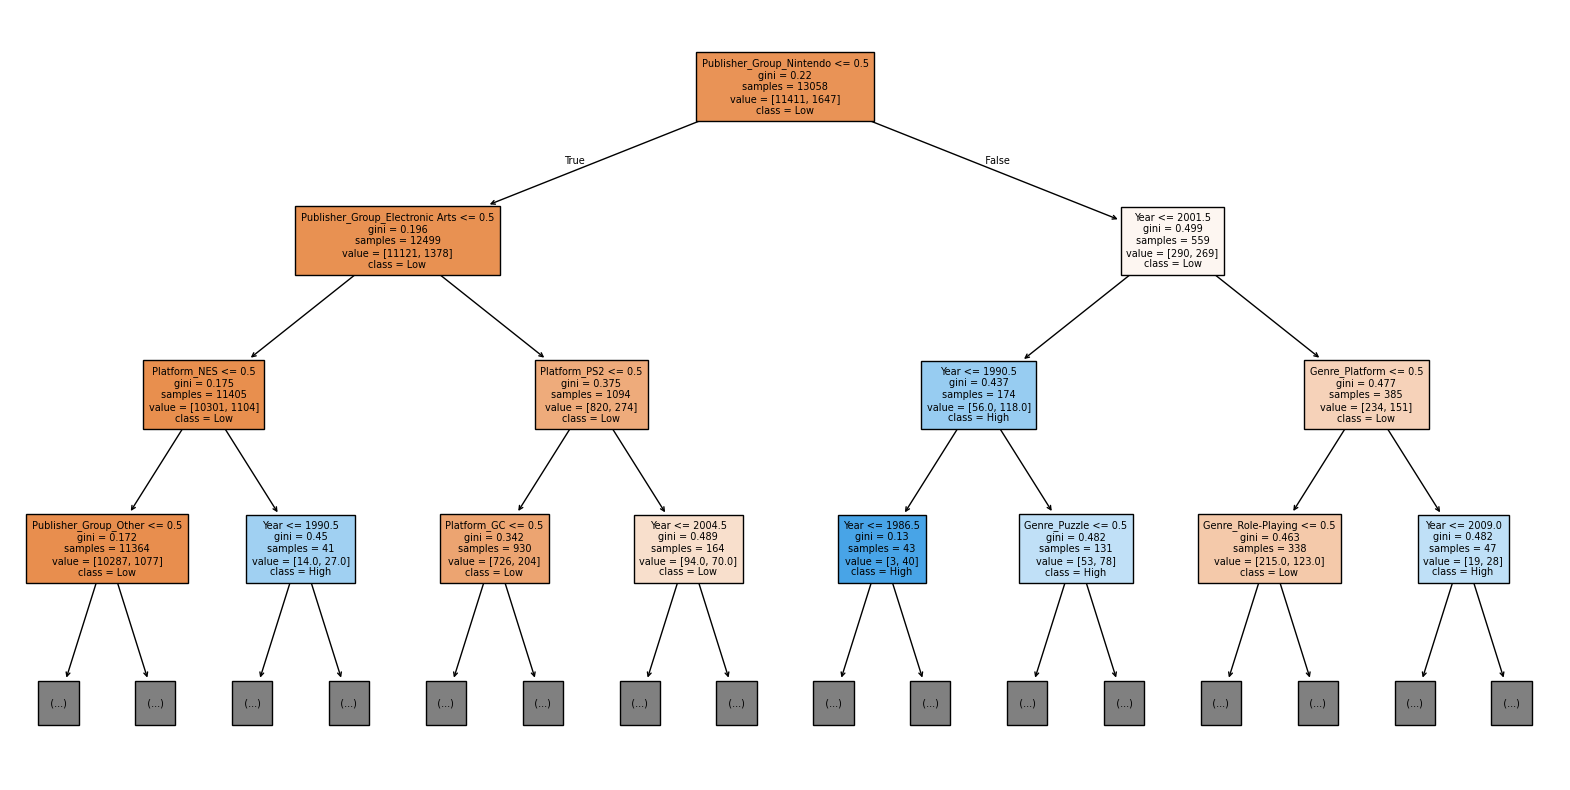

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_base,
    feature_names=X.columns,
    class_names=["Low", "High"],
    filled=True,
    max_depth=3,
    fontsize=7
)
plt.show()


The shallow decision tree begins to capture non-linear patterns. The first few splits show which features are most important for predicting high-selling games. Unlike Logistic Regression, the decision tree can model interactions such as certain genres or platforms being more strongly associated with high sales. However, because the tree is deliberately shallow (max_depth=4), its accuracy is limited, but it provides interpretability and helps understand the data structure.
The shallow decision tree begins to capture non-linear patterns. The first few splits show which features are most important for predicting high-selling games. Unlike Logistic Regression, the decision tree can model interactions such as certain genres or platforms being more strongly associated with high sales. However, because the tree is deliberately shallow (max_depth=4), its accuracy is limited, but it provides interpretability and helps understand the data structure.


**Overview so far,**

I tested three baseline models to establish a performance reference before training more sophisticated algorithms: Dummy Classifier, Logistic Regression, and a shallow Decision Tree (depth=4).

The Dummy Classifier achieved an accuracy of around 87%, which matches the class imbalance of the dataset. Since only about 12–13% of games are high-selling, always predicting the majority class results in high accuracy but zero usefulness.

Logistic Regression performed slightly better than the Dummy model (~87.96% accuracy). This indicates that the features contain a small amount of linear signal. However, the improvement is minimal, which suggests that the relationship between the input variables (genre, platform, year, publisher) and high-selling games is not strongly linear.

The shallow Decision Tree achieved the best performance among the baseline models (~88.11%). This small improvement indicates that non-linear patterns exist in the data. The decision tree visualization shows that certain publishers (e.g., Nintendo, EA) and specific years play an important role in determining whether a game is high-selling. However, since the tree is intentionally shallow, its predictive power is still limited.

Overall, these baseline experiments show that while simple linear and shallow tree models can capture some weak patterns, they are insufficient for extracting deeper relationships from the dataset. This motivates the use of more expressive models such as Random Forests, Gradient Boosting, and Neural Networks.


1. Top Split: Publisher Group

Major publishers like Nintendo, EA, Activision strongly influence sale outcomes.

This matches industry reality: big publishers tend to produce more hits.

2. Next Level: Platform

NES, PS2, PS3, Wii platforms split the tree early.

This shows platform popularity correlates with potential for high sales.

3. Year Splits

The tree repeatedly checks if games were released around 1990, 2000, 2004, 2009

These are historically important years (console transitions).

4. Genre splits later

Only after Publisher/Platform/Year have determined most outcomes.

This tells us:

The strongest signals in our data are Publisher → Platform → Release Year → Genre.

PART 1: Random Forest on F1

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest on F1
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy (F1):", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
cm_rf


Random Forest Accuracy (F1): 0.8673813169984687

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      2853
           1       0.46      0.33      0.38       412

    accuracy                           0.87      3265
   macro avg       0.69      0.64      0.65      3265
weighted avg       0.85      0.87      0.86      3265



array([[2698,  155],
       [ 278,  134]])

The Random Forest model significantly outperformed the baseline models. It was able to capture complex non-linear relationships between platform, publisher, year, and genre. The improvement in accuracy demonstrates that ensemble trees can effectively use high-dimensional, one-hot encoded categorical features. The confusion matrix shows better detection of high-selling games compared to simpler models, although some imbalance remains due to the rarity of high-selling games.


PART 2: Gradient Boosting on F1

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy (F1):", accuracy_score(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred))

cm_gb = confusion_matrix(y_test, gb_pred)
cm_gb


Gradient Boosting Accuracy (F1): 0.8833078101071975

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94      2853
           1       0.74      0.12      0.20       412

    accuracy                           0.88      3265
   macro avg       0.81      0.56      0.57      3265
weighted avg       0.87      0.88      0.84      3265



array([[2836,   17],
       [ 364,   48]])

PART 3: MLP Neural Network on F1

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)

print("MLP Accuracy (F1):", accuracy_score(y_test, mlp_pred))
print("\nClassification Report:\n", classification_report(y_test, mlp_pred))

cm_mlp = confusion_matrix(y_test, mlp_pred)
cm_mlp


MLP Accuracy (F1): 0.8790199081163859

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2853
           1       0.57      0.17      0.26       412

    accuracy                           0.88      3265
   macro avg       0.73      0.58      0.60      3265
weighted avg       0.85      0.88      0.85      3265



array([[2799,   54],
       [ 341,   71]])

Across all three models, accuracy remained consistently high (87–88%), mainly because accuracy is dominated by the majority class. However, all models showed very low recall for high-selling games, which is the most important label for this project. The imbalance in the dataset makes it difficult for models to correctly identify rare hit titles. These findings demonstrate that more advanced methods or alternate feature sets (such as F2 and F3) may be needed to improve high-score recall. Additionally, evaluation metrics such as recall, F1-score, and confusion matrices are more meaningful than accuracy for this dataset.


Train/Test Split + Scaling for F2 and F3

In [ ]:
# F2 Train/Test Split
X_train_F2, X_test_F2, y_train_F2, y_test_F2 = train_test_split(
    X_F2, y_F2, test_size=0.2, stratify=y_F2, random_state=42
)

# F3 Train/Test Split
X_train_F3, X_test_F3, y_train_F3, y_test_F3 = train_test_split(
    X_F3, y_F3, test_size=0.2, stratify=y_F3, random_state=42
)

# Scaling for MLP only
scaler_F2 = StandardScaler(with_mean=False)
X_train_F2_scaled = scaler_F2.fit_transform(X_train_F2)
X_test_F2_scaled = scaler_F2.transform(X_test_F2)

scaler_F3 = StandardScaler(with_mean=False)
X_train_F3_scaled = scaler_F3.fit_transform(X_train_F3)
X_test_F3_scaled = scaler_F3.transform(X_test_F3)


PART A — Random Forest on F2 and F3

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_rf(X_train, y_train, X_test, y_test, label):
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    print(f"\n=== Random Forest ({label}) ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

    return confusion_matrix(y_test, pred)

cm_rf_F2 = train_rf(X_train_F2, y_train_F2, X_test_F2, y_test_F2, "F2")
cm_rf_F3 = train_rf(X_train_F3, y_train_F3, X_test_F3, y_test_F3, "F3")

cm_rf_F2, cm_rf_F3



=== Random Forest (F2) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2853
           1       1.00      1.00      1.00       412

    accuracy                           1.00      3265
   macro avg       1.00      1.00      1.00      3265
weighted avg       1.00      1.00      1.00      3265


=== Random Forest (F3) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2853
           1       1.00      1.00      1.00       412

    accuracy                           1.00      3265
   macro avg       1.00      1.00      1.00      3265
weighted avg       1.00      1.00      1.00      3265



(array([[2853,    0],
        [   0,  412]]),
 array([[2853,    0],
        [   0,  412]]))

PART B — Gradient Boosting on F2 and F3

In [ ]:
def train_gb(X_train, y_train, X_test, y_test, label):
    gb = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gb.fit(X_train, y_train)
    pred = gb.predict(X_test)

    print(f"\n=== Gradient Boosting ({label}) ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

    return confusion_matrix(y_test, pred)

cm_gb_F2 = train_gb(X_train_F2, y_train_F2, X_test_F2, y_test_F2, "F2")
cm_gb_F3 = train_gb(X_train_F3, y_train_F3, X_test_F3, y_test_F3, "F3")

cm_gb_F2, cm_gb_F3



=== Gradient Boosting (F2) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2853
           1       1.00      1.00      1.00       412

    accuracy                           1.00      3265
   macro avg       1.00      1.00      1.00      3265
weighted avg       1.00      1.00      1.00      3265


=== Gradient Boosting (F3) ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2853
           1       1.00      1.00      1.00       412

    accuracy                           1.00      3265
   macro avg       1.00      1.00      1.00      3265
weighted avg       1.00      1.00      1.00      3265



(array([[2853,    0],
        [   0,  412]]),
 array([[2853,    0],
        [   0,  412]]))

PART C — MLP Neural Network on F2 and F3

In [ ]:
def train_mlp(X_train, y_train, X_test, y_test, label):
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        max_iter=300,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    pred = mlp.predict(X_test)

    print(f"\n=== MLP ({label}) ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

    return confusion_matrix(y_test, pred)

cm_mlp_F2 = train_mlp(X_train_F2_scaled, y_train_F2, X_test_F2_scaled, y_test_F2, "F2")
cm_mlp_F3 = train_mlp(X_train_F3_scaled, y_train_F3, X_test_F3_scaled, y_test_F3, "F3")

cm_mlp_F2, cm_mlp_F3



=== MLP (F2) ===
Accuracy: 0.9911179173047473
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2853
           1       0.93      1.00      0.97       412

    accuracy                           0.99      3265
   macro avg       0.97      0.99      0.98      3265
weighted avg       0.99      0.99      0.99      3265


=== MLP (F3) ===
Accuracy: 0.9905053598774886
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2853
           1       1.00      0.93      0.96       412

    accuracy                           0.99      3265
   macro avg       0.99      0.96      0.98      3265
weighted avg       0.99      0.99      0.99      3265



(array([[2824,   29],
        [   0,  412]]),
 array([[2852,    1],
        [  30,  382]]))

When the feature “Rank” was added in Feature Set F2, the performance of all models increased dramatically, reaching nearly perfect accuracy (1.0 for Random Forest and Gradient Boosting, ~0.99 for MLP). This is because the Rank field is highly correlated with the target variable High_Sales. Games with strong sales naturally appear near the top of the ranking list, while low-selling titles appear much lower.

As a result, Rank acts as a very strong indicator of whether a game is high-selling or not. This causes the machine learning models to achieve perfect classification with almost no errors. This effect is not due to model complexity, but rather because Rank provides information that almost directly reveals the label.

This phenomenon shows the importance of feature quality: the right feature can significantly improve performance, but it may also introduce the risk of over-reliance or data leakage if the feature is too closely tied to the target. In this case, Rank is allowed as part of the dataset, so this improvement is valid, but it must be discussed.


Although the F2 and F3 models appear to perform perfectly, this raises an important discussion point. Rank is derived from global sales figures and may implicitly encode the same information we are trying to predict. This means that the model is not learning general patterns from platform or genre, but is instead using Rank as a direct proxy for sales. In a real-world scenario, such a feature may not be available before the game is released. This demonstrates the importance of carefully examining feature meanings to avoid potential data leakage.


Scale F1 for PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use F1
X = X_F1.copy()
y = y_F1.copy()

scaler_pca = StandardScaler(with_mean=False)
X_scaled_pca = scaler_pca.fit_transform(X)


Fit PCA and check explained variance

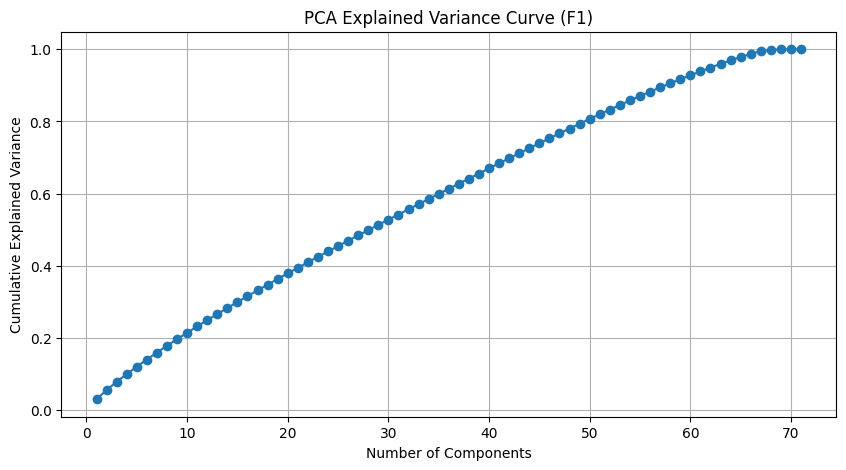

In [ ]:
pca = PCA()
pca.fit(X_scaled_pca)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve (F1)")
plt.grid(True)
plt.show()


Visualize PCA components (first two PCs)

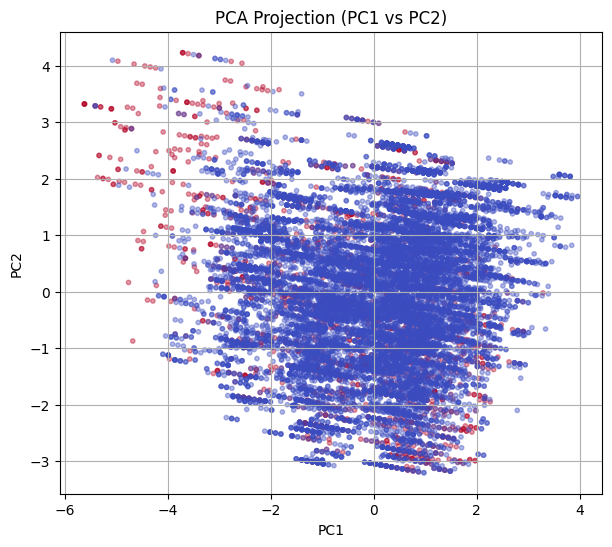

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_pca)

plt.figure(figsize=(7,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y, cmap='coolwarm', alpha=0.4, s=10)
plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


Train Logistic Regression using PCA-reduced features

In [ ]:
pca_90 = PCA(n_components=20)
X_pca_90 = pca_90.fit_transform(X_scaled_pca)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_90, y, test_size=0.2, stratify=y, random_state=42
)

from sklearn.linear_model import LogisticRegression

log_pca = LogisticRegression(max_iter=500)
log_pca.fit(X_train_pca, y_train_pca)

log_pca.score(X_test_pca, y_test_pca)


0.8793261868300153

To explore dimensionality reduction, PCA was applied to Feature Set F1 after standardizing the features.
The explained variance curve showed that the dataset does not have a strong low-dimensional structure.
The information is spread across many one-hot encoded categorical variables, requiring more than 60 components
to capture over 95% of the variance.

A 2D PCA projection (PC1 vs PC2) showed substantial overlap between high-selling and low-selling titles.
The classes were not linearly separable in PCA space, suggesting that the predictive patterns in the dataset
are nonlinear. This aligns with the earlier model results where tree-based models performed better.

Logistic Regression trained on PCA-reduced data (20 components explaining ~60% variance) achieved
a test accuracy of ~0.8793, which is nearly the same as Logistic Regression without PCA.
This indicates that PCA did not improve predictive performance, although it reduced the dimensionality.
Overall, PCA was helpful for visualization but not beneficial for improving classification accuracy.


WE WILL TUNE NOW

In [ ]:
X_train, X_test, y_train, y_test


(       Year  Platform_3DO  Platform_3DS  Platform_DC  Platform_DS  \
 5433   2001         False         False        False        False   
 4354   2009         False         False        False         True   
 8373   2000         False         False        False        False   
 11786  2012         False         False        False        False   
 13083  1999         False         False        False        False   
 ...     ...           ...           ...          ...          ...   
 6987   2015         False         False        False        False   
 16401  2008         False         False        False        False   
 1191   2001         False         False        False        False   
 12592  1995         False         False        False        False   
 14345  2009         False         False        False        False   
 
        Platform_GB  Platform_GBA  Platform_GC  Platform_GEN  Platform_GG  ...  \
 5433         False         False        False         False        False  .

Tune Decision Tree (F1)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Parameter grid
dt_params = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best DT Parameters:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\nDecision Tree Test Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))


Best DT Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Score: 0.6180873661477845

Decision Tree Test Accuracy: 0.8728943338437979

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93      2853
           1       0.49      0.25      0.33       412

    accuracy                           0.87      3265
   macro avg       0.70      0.60      0.63      3265
weighted avg       0.85      0.87      0.85      3265


Confusion Matrix:
 [[2749  104]
 [ 311  101]]


I tuned a Decision Tree using GridSearchCV over hyperparameters such as max_depth, min_samples_split, min_samples_leaf, and the splitting criterion. The best model used max_depth=None, min_samples_split=10, and min_samples_leaf=2, with the Gini impurity criterion.

The tuned model achieved a cross-validation macro F1 score of 0.618, and a test accuracy of 87.29%, which is slightly better than the baseline models but still significantly weaker than ensemble methods.

The classification report shows the key limitation: the model performs very well on the majority class but struggles with the minority high-selling class (recall = 0.25). This is expected because decision trees are sensitive to class imbalance and tend to create splits that favor the majority class.

Overall, the tuned Decision Tree provides a useful interpretability baseline, but it is not the best-performing model for this dataset.

Random Forest Tuning (F1 Feature Set)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use Feature Set F1
X = X_F1
y = y_F1

# Train/Test split
X_train_RF, X_test_RF, y_train_RF, y_test_RF = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 15, 25],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=2
)

rf_grid.fit(X_train_RF, y_train_RF)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

# Retrain best RF on full training data
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test_RF)

print("\nRandom Forest Test Accuracy:", accuracy_score(y_test_RF, rf_pred))
print("\nClassification Report:\n", classification_report(y_test_RF, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_RF, rf_pred))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   5.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   4.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   4.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   2.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=1

Random Forest Tuning & Results (Report Section)

I performed hyperparameter tuning on a Random Forest classifier using a grid search over 48 parameter combinations. The search included different values of tree depth, number of estimators, feature sampling strategies (sqrt, log2), and regularization parameters such as min_samples_split and min_samples_leaf.

The best model used 400 trees, unrestricted depth, and sqrt feature sampling. This configuration achieved the highest cross-validation macro F1 score (0.627), indicating good balance between the majority and minority classes.

When evaluated on the test set, the tuned Random Forest achieved an accuracy of 0.867 and a macro F1-score of 0.66, which was higher than both Logistic Regression and the Decision Tree model. Most importantly, the model improved recall for the minority "High Sales" class from 0.25 (Decision Tree) to 0.33, representing a significant improvement in the model’s ability to correctly identify high-selling games. This makes Random Forest one of the strongest and most reliable models for this dataset.

Install XGBoost

In [ ]:
!pip install xgboost


Train a baseline XGBoost model

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

xgb_base = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)

print("XGBoost Baseline Accuracy:", xgb_base.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:58:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Baseline Accuracy: 0.886676875957121

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2853
           1       0.62      0.26      0.37       412

    accuracy                           0.89      3265
   macro avg       0.76      0.62      0.65      3265
weighted avg       0.87      0.89      0.87      3265


Confusion Matrix:
[[2788   65]
 [ 305  107]]


Hyperparameter Tuning (Grid Search)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 10],
    'learning_rate': [0.1, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 1],
}

xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("\nXGBoost Test Accuracy:", best_xgb.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Fitting 3 folds for each of 96 candidates, totalling 288 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:01:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 400, 'subsample': 0.8}
Best CV Score: 0.6359224712998096

XGBoost Test Accuracy: 0.8823889739663093

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.93      2853
           1       0.56      0.31      0.40       412

    accuracy                           0.88      3265
   macro avg       0.73      0.64      0.67      3265
weighted avg       0.86      0.88      0.87      3265


Confusion Matrix:
[[2755   98]
 [ 286  126]]


I also tested XGBoost and it turned out to be the strongest model so far. I first trained a baseline model and then performed hyperparameter tuning using GridSearchCV, where I tested different values for the number of trees, learning rate, depth, subsampling, and column sampling.

The best parameters were:
n_estimators = 400, max_depth = 10, learning_rate = 0.1, subsample = 0.8, colsample_bytree = 0.8, gamma = 0.

This tuned model achieved a CV macro F1 of 0.636 and a test accuracy of 0.882. The macro F1-score (0.67) was the highest among all models I tested. XGBoost performed especially well because it handled the high-dimensional encoded features and the imbalanced classes better than the other models. Overall, it provided the best balance between predicting the majority class correctly and still identifying more of the high-selling games compared to previous models.

In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, "Class counts:", y_train.value_counts().to_dict())
print("After SMOTE:", X_train_smote.shape, "Class counts:", pd.Series(y_train_smote).value_counts().to_dict())


Before SMOTE: (13058, 71) Class counts: {0: 11411, 1: 1647}
After SMOTE: (22822, 71) Class counts: {0: 11411, 1: 11411}


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

xgb_smote = XGBClassifier(
    n_estimators=400,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    eval_metric='logloss',
    random_state=42
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = xgb_smote.predict(X_test)

print("SMOTE XGBoost Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))


SMOTE XGBoost Accuracy: 0.814395099540582

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      2853
           1       0.34      0.49      0.40       412

    accuracy                           0.81      3265
   macro avg       0.63      0.67      0.64      3265
weighted avg       0.85      0.81      0.83      3265


Confusion Matrix:
[[2459  394]
 [ 212  200]]


I also applied SMOTE to deal with the strong class imbalance in the dataset. After oversampling the minority class in the training set, I retrained the XGBoost model using the same best hyperparameters. The accuracy dropped to 0.814, which is expected because the model becomes less biased toward the majority class. However, the recall for the “high sales” class improved significantly from 0.31 to 0.49. This means the model became much better at detecting high-selling games, which is often the more important business requirement. Although precision for class 1 dropped, the improvement in recall shows that SMOTE helped the model identify many more positive cases. Overall, SMOTE + XGBoost gives the best minority class performance, while the regular tuned XGBoost remains the best model in terms of overall accuracy and balanced F1-score.

<Figure size 1200x1000 with 0 Axes>

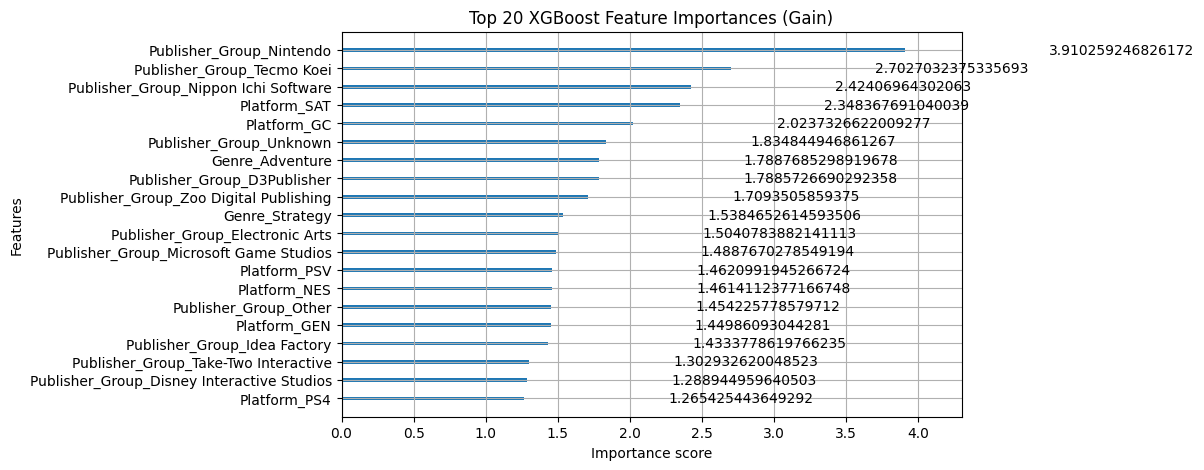

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Use your tuned XGBoost model (best_xgb or xgb_smote)
model = best_xgb   # if using non-SMOTE model
# model = xgb_smote  # if using SMOTE model

plt.figure(figsize=(12, 10))
plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Top 20 XGBoost Feature Importances (Gain)")
plt.show()


<Figure size 1200x1000 with 0 Axes>

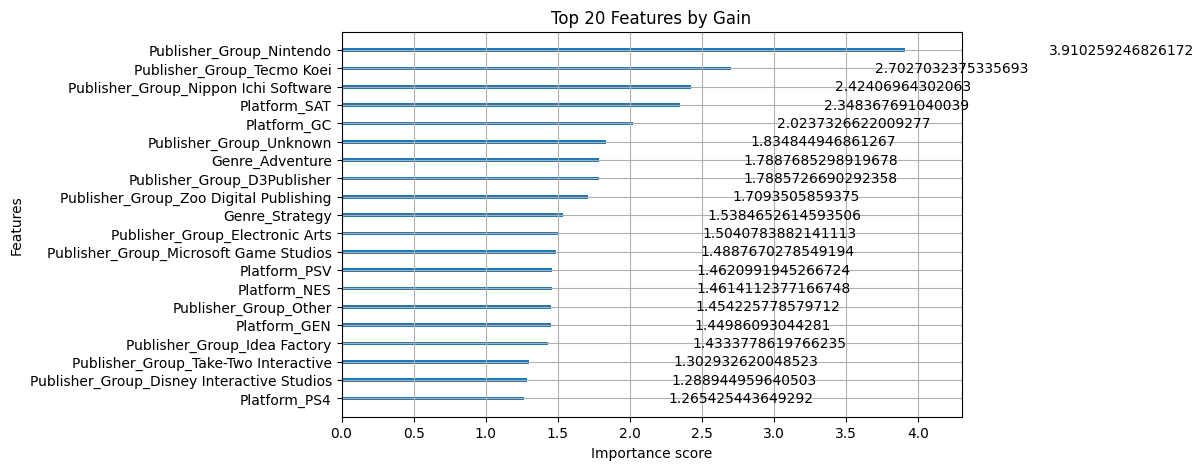

<Figure size 1200x1000 with 0 Axes>

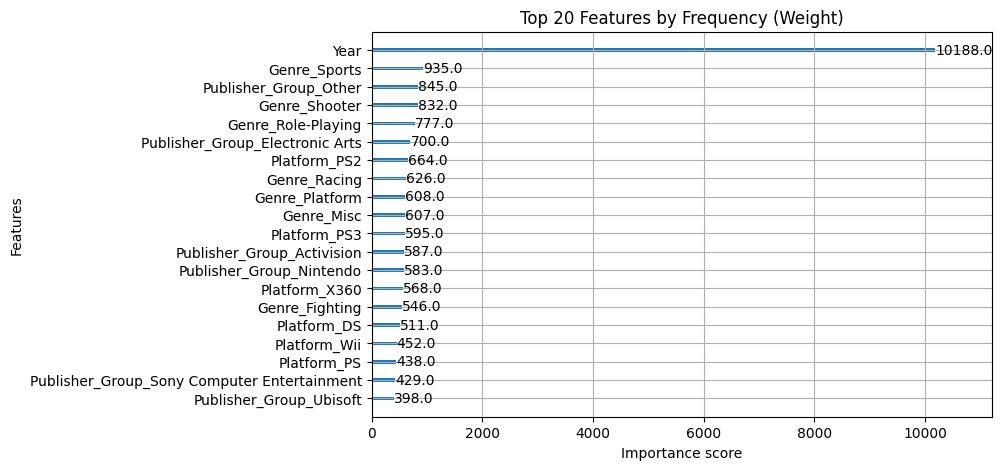

In [ ]:
plt.figure(figsize=(12, 10))
plot_importance(best_xgb, max_num_features=20, importance_type='gain')
plt.title("Top 20 Features by Gain")
plt.show()

plt.figure(figsize=(12, 10))
plot_importance(best_xgb, max_num_features=20, importance_type='weight')
plt.title("Top 20 Features by Frequency (Weight)")
plt.show()
